In [2]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

-------- (Shots = 1000, Realizations = 50) --------
Evaluating N_train = 10...
Density matrices generated.
Expectation values computed.


<string>:42: ComplexWarning: Casting complex values to real discards the imaginary part
<string>:39: ComplexWarning: Casting complex values to real discards the imaginary part


Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Expectation values computed.
Density matrices generated.
Exp

/Users/gianmarcoferrara/ML/QELMvsKER/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gianmarcoferrara/ML/QELMvsKER/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/gianmarcoferrara/ML/QELMvsKER/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


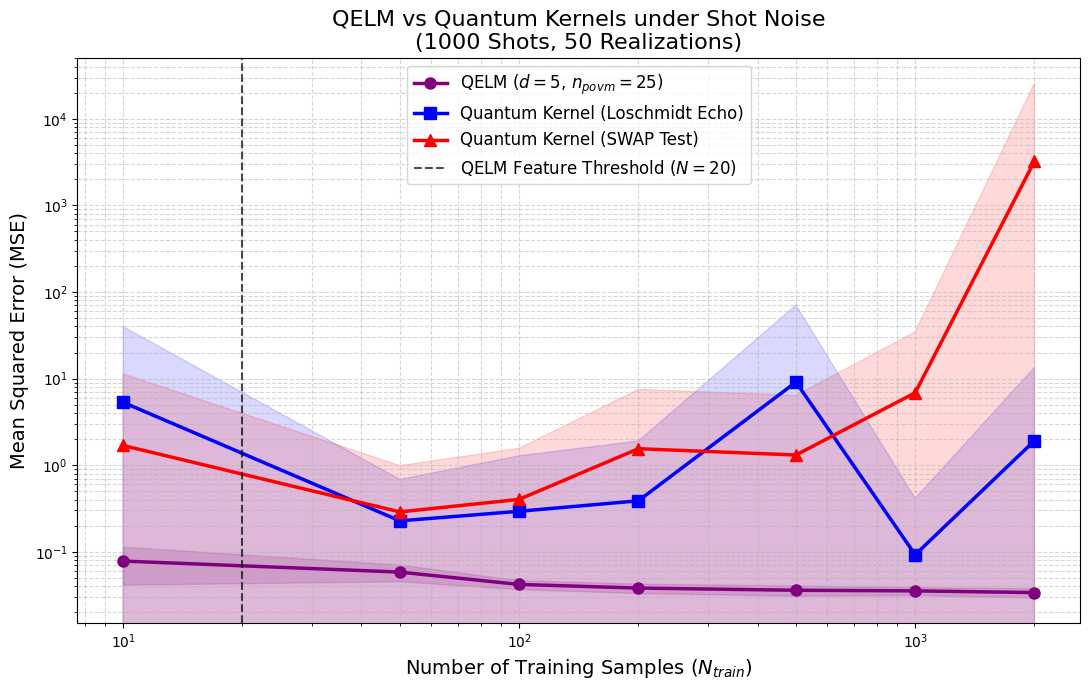

In [ ]:
####### Settings #########
N_train_list = [10, 50, 100, 200, 500, 1000, 2000]
N_test = 200
num_realizations = 50
num_shots = 1000

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
num_povm_elements = 20



# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices()
        ds.compute_expectation_values()
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        povm = myQML.generate_random_povm(d_res, num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict(rho_test) - y_test)**2))

    # Store results
    for key in results.keys():
        results[key].append(np.mean(mse_runs[key]))
        stds[key].append(np.std(mse_runs[key]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# Plot
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$, $n_{povm}=20$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


-------- (Shots = 100, Realizations = 40) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.0775+0.0000j
  -> K-LE MSE: 4.8326+0.0000j
  -> K-SW MSE: 0.5018+0.0000j
  -> Time:     46.5s
Evaluating N_train = 50...
  -> QELM MSE: 0.0686+0.0000j
  -> K-LE MSE: 0.5360+0.0000j
  -> K-SW MSE: 4.7374+0.0000j
  -> Time:     78.4s
Evaluating N_train = 100...
  -> QELM MSE: 0.0483+0.0000j
  -> K-LE MSE: 0.4175+0.0000j
  -> K-SW MSE: 8.4977+0.0000j
  -> Time:     96.1s
Evaluating N_train = 200...
  -> QELM MSE: 0.0419+0.0000j
  -> K-LE MSE: 70.0828+0.0000j
  -> K-SW MSE: 902.0776+0.0000j
  -> Time:     220.5s
Evaluating N_train = 500...
  -> QELM MSE: 0.0400+0.0000j
  -> K-LE MSE: 1.0604+0.0000j
  -> K-SW MSE: 2.3449+0.0000j
  -> Time:     1486.7s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0387+0.0000j
  -> K-LE MSE: 0.6811+0.0000j
  -> K-SW MSE: 6.9801+0.0000j
  -> Time:     4948.1s
Experiment finished in 114.6 minutes.


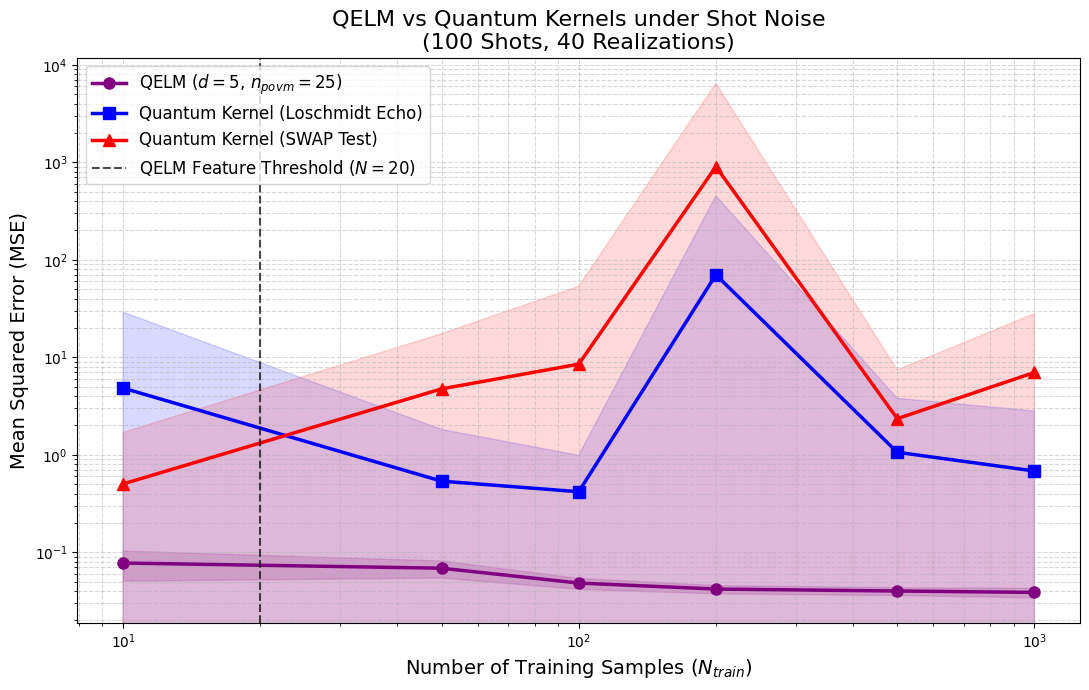

In [6]:
####### Settings #########
N_train_list = [10, 50, 100, 200, 500, 1000]
N_test = 200
num_realizations = 40
num_shots = 100

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
num_povm_elements = 20



# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices()
        ds.compute_expectation_values()
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        povm = myQML.generate_random_povm(d_res, num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict(rho_test) - y_test)**2))

    # Store results
    for key in results.keys():
        results[key].append(np.mean(mse_runs[key]))
        stds[key].append(np.std(mse_runs[key]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# Plot
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=5$, $n_{povm}=25$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

# Add feature threshold line for QELM
plt.axvline(x=num_povm_elements, color='black', linestyle='--', alpha=0.7, 
            label=f'QELM Feature Threshold ($N = {num_povm_elements}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

-------- (Shots = 10, Realizations = 50) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.0921+0.0000j
  -> K-LE MSE: 1.7331+0.0000j
  -> K-SW MSE: 28.7648+0.0000j
  -> Time:     61.0s
Evaluating N_train = 50...
  -> QELM MSE: 0.0662+0.0000j
  -> K-LE MSE: 145.8002+0.0000j
  -> K-SW MSE: 20.0835+0.0000j
  -> Time:     92.1s
Evaluating N_train = 100...
  -> QELM MSE: 0.0505+0.0000j
  -> K-LE MSE: 60.1577+0.0000j
  -> K-SW MSE: 13.9113+0.0000j
  -> Time:     141.8s
Evaluating N_train = 200...
  -> QELM MSE: 0.0443+0.0000j
  -> K-LE MSE: 12.8049+0.0000j
  -> K-SW MSE: 18.9087+0.0000j
  -> Time:     253.0s
Evaluating N_train = 500...
  -> QELM MSE: 0.0412+0.0000j
  -> K-LE MSE: 13.1785+0.0000j
  -> K-SW MSE: 3489.3351+0.0000j
  -> Time:     877.4s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0397+0.0000j
  -> K-LE MSE: 3873.2793+0.0000j
  -> K-SW MSE: 14091.7198+0.0000j
  -> Time:     2547.0s
Evaluating N_train = 2000...
  -> QELM MSE: 0.0394+0.0000j
  -> K-LE MSE: 50.6475+0.0000j
  -

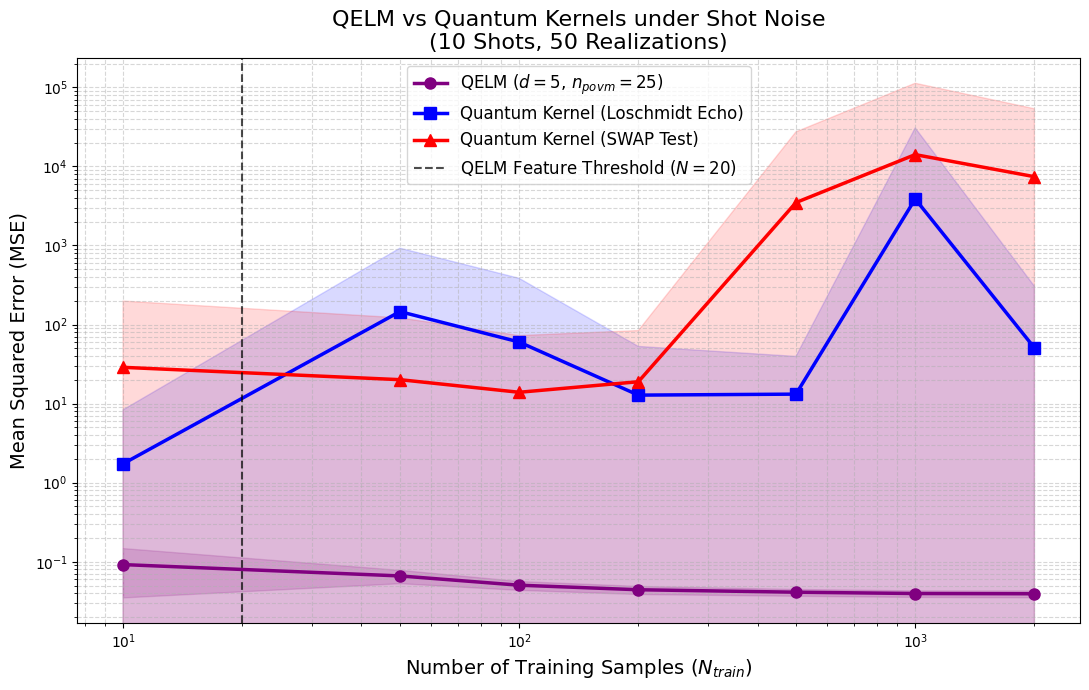

In [7]:
####### Settings #########
N_train_list = [10, 50, 100, 200, 500, 1000, 2000]
N_test = 200
num_realizations = 50
num_shots = 10

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
num_povm_elements = 20



# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices()
        ds.compute_expectation_values()
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        povm = myQML.generate_random_povm(d_res, num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict(rho_test) - y_test)**2))

    # Store results
    for key in results.keys():
        results[key].append(np.mean(mse_runs[key]))
        stds[key].append(np.std(mse_runs[key]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# Plot
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=5$, $n_{povm}=25$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

# Add feature threshold line for QELM
plt.axvline(x=num_povm_elements, color='black', linestyle='--', alpha=0.7, 
            label=f'QELM Feature Threshold ($N = {num_povm_elements}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

-------- (Shots = 0, Realizations = 50) --------
Evaluating N_train = 10...


<string>:61: ComplexWarning: Casting complex values to real discards the imaginary part
<string>:63: ComplexWarning: Casting complex values to real discards the imaginary part
<string>:82: ComplexWarning: Casting complex values to real discards the imaginary part


  -> QELM MSE: 0.0000+0.0000j
  -> K-LE MSE: 0.0000+0.0000j
  -> K-SW MSE: 0.0000+0.0000j
  -> Time:     58.1s
Evaluating N_train = 50...
  -> QELM MSE: 0.0000+0.0000j
  -> K-LE MSE: 0.0000+0.0000j
  -> K-SW MSE: 0.0000+0.0000j
  -> Time:     86.7s
Evaluating N_train = 100...
  -> QELM MSE: 0.0000+0.0000j
  -> K-LE MSE: 0.0000+0.0000j
  -> K-SW MSE: 0.0000+0.0000j
  -> Time:     129.4s
Evaluating N_train = 200...
  -> QELM MSE: 0.0000+0.0000j
  -> K-LE MSE: 0.0000+0.0000j
  -> K-SW MSE: 0.0000+0.0000j
  -> Time:     227.1s
Evaluating N_train = 500...
  -> QELM MSE: 0.0000+0.0000j
  -> K-LE MSE: 0.0000+0.0000j
  -> K-SW MSE: 0.0000+0.0000j
  -> Time:     657.1s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0000+0.0000j
  -> K-LE MSE: 0.0000+0.0000j
  -> K-SW MSE: 0.0000+0.0000j
  -> Time:     2026.5s
Evaluating N_train = 2000...
  -> QELM MSE: 0.0000+0.0000j
  -> K-LE MSE: 0.0000+0.0000j
  -> K-SW MSE: 0.0000+0.0000j
  -> Time:     16699.7s
Experiment finished in 331.4 minutes.


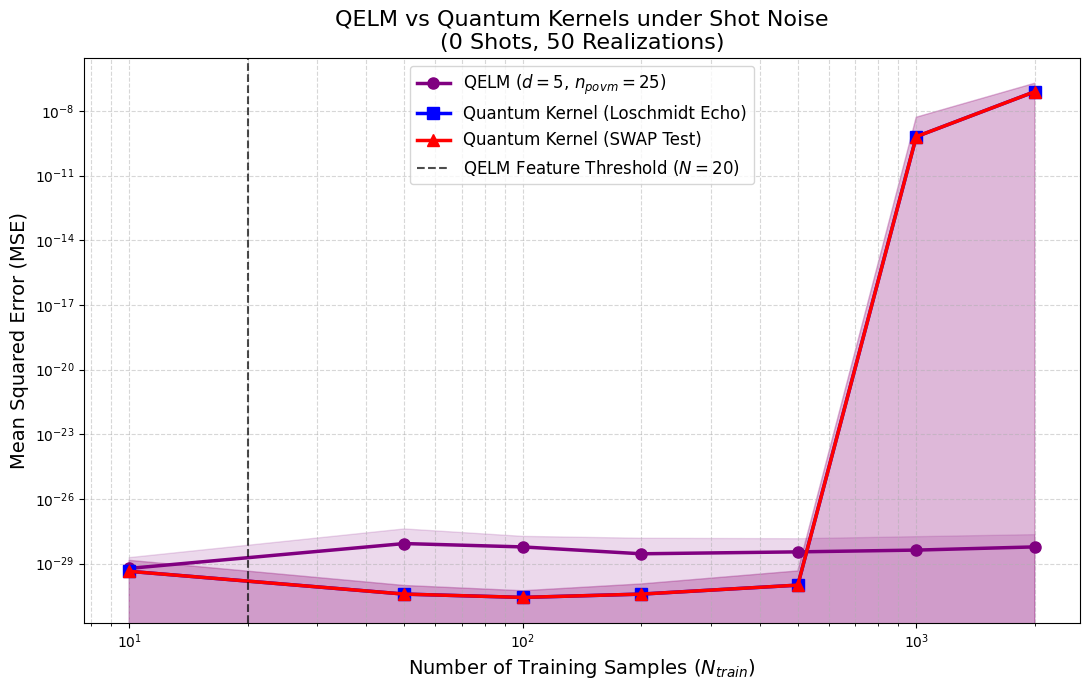

In [8]:
####### Settings #########
N_train_list = [10, 50, 100, 200, 500, 1000, 2000]
N_test = 200
num_realizations = 50
num_shots = 0

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
num_povm_elements = 20



# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices()
        ds.compute_expectation_values()
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        povm = myQML.generate_random_povm(d_res, num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict(rho_test) - y_test)**2))

    # Store results
    for key in results.keys():
        results[key].append(np.mean(mse_runs[key]))
        stds[key].append(np.std(mse_runs[key]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# Plot
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=5$, $n_{povm}=25$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

# Add feature threshold line for QELM
plt.axvline(x=num_povm_elements, color='black', linestyle='--', alpha=0.7, 
            label=f'QELM Feature Threshold ($N = {num_povm_elements}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
####### Helper Function #########
def get_n_qubit_observable(n, base_op):
    """
    Generates an n-qubit observable by taking the tensor product 
    of the base_op n times. E.g., for base_op = X, returns X^otimes n.
    """
    obs = base_op
    for _ in range(n - 1):
        obs = np.kron(obs, base_op)
    return obs

####### Settings #########
n_qubits_list = [1, 2, 3, 4, 5] # The number of qubits (n) to loop over
N_train = 100                # FIXED number of training samples
N_test = 200                 # FIXED number of test samples
num_realizations = 40
num_shots = 1000

reg_lambda = 0

# QELM reservoir physical setup (Fixed part)
d_res = 64
num_povm_elements = 20

# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Fixed N_train = {N_train}, Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# Loop over the number of qubits instead of training samples
for n in n_qubits_list:
    d_in = 2**n              # Dynamic dimension of the input state
    d_out = d_in * d_res     # Dynamic output dimension
    
    print(f"Evaluating n = {n} qubits (d_in = {d_in})...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    # Generate the n-qubit observable (e.g., X \otimes X \dots)
    obs_n = get_n_qubit_observable(n, myQML.X)

    for r in range(num_realizations):
        # Pass the n-qubit observable; the generator will infer d = 2^n
        ds = myQML.QuantumDatasetGenerator2(N_train, N_test, obs_n)
        ds.generate_density_matrices()
        ds.compute_expectation_values()
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        # Isometry and POVM depend dynamically on d_in for the current n
        V = myQML.random_isometry(d_in, d_out)
        povm = myQML.generate_random_povm(d_res, num_povm_elements)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict(rho_test) - y_test)**2))

    # Store results
    for key in results.keys():
        results[key].append(np.mean(mse_runs[key]))
        stds[key].append(np.std(mse_runs[key]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# Plot
plt.figure(figsize=(11, 7))
n_arr = np.array(n_qubits_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': f'QELM ($d_{{res}}={d_res}$, $n_{{povm}}={num_povm_elements}$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    std_arr = np.array(stds[model])
    
    plt.plot(n_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(n_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

# (Note: The axvline for QELM Feature Threshold was removed because 
# the X-axis is no longer N_train, so a threshold on N_train doesn't apply here)

# Only use integer ticks for number of qubits
plt.xticks(n_qubits_list) 

plt.yscale('log') # Log scale for MSE is good, but X-axis is now linear (1, 2, 3...)
plt.xlabel('($n$) dimension of input space $d=2^n$', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Scaling with System Size: QELM vs Quantum Kernels\n(Fixed $N_{{train}} = {N_train}$, {num_shots} Shots)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

-------- (Fixed N_train = 100, Shots = 1000, Realizations = 40) --------
Evaluating n = 1 qubits (d_in = 2)...


/Users/gianmarcoferrara/ML/QELMvsKER/myQMLlib/quantumkernel.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  measured_successes = np.random.binomial(n=self.num_shots, p=HS_rho1_rho2)
/Users/gianmarcoferrara/ML/QELMvsKER/myQMLlib/quantumkernel.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  measured_successes = np.random.binomial(n=self.num_shots, p = 0.5 * (1.0 + HS_rho1_rho2))


  -> QELM MSE: 0.0440
  -> K-LE MSE: 0.2525
  -> K-SW MSE: 1.1964
  -> Time:     140.6s
Evaluating n = 2 qubits (d_in = 4)...
  -> QELM MSE: 0.0121
  -> K-LE MSE: 3.1136
  -> K-SW MSE: 16.8590
  -> Time:     125.7s
Evaluating n = 3 qubits (d_in = 8)...
  -> QELM MSE: 0.0031
  -> K-LE MSE: 4.6125
  -> K-SW MSE: 3.4268
  -> Time:     168.3s
Evaluating n = 4 qubits (d_in = 16)...
  -> QELM MSE: 0.0008
  -> K-LE MSE: 0.1503
  -> K-SW MSE: 0.6217
  -> Time:     422.0s
Evaluating n = 5 qubits (d_in = 32)...
